<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/TradingStrategies/TradingStrategies/Mean_Reversion_Strategy_%2B_Statistical_Arbitrage(Pairs_Trading).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

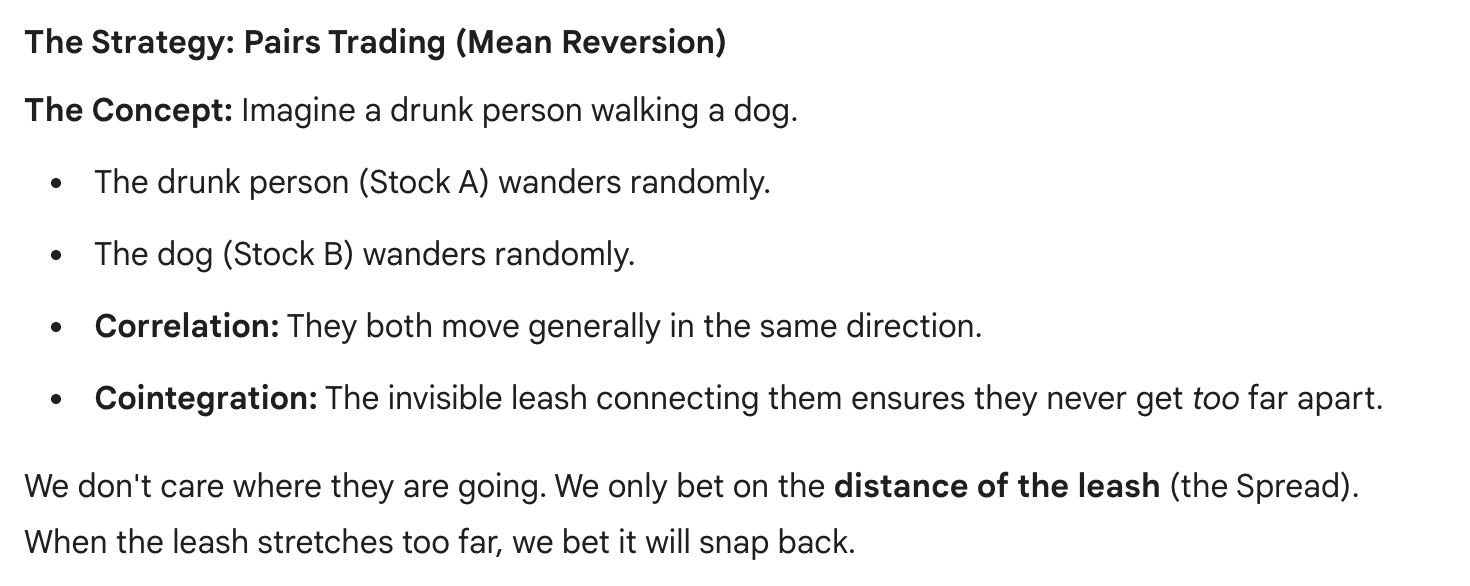

In [17]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm
from scipy import stats

In [2]:
# --- CONFIGURATION ---
pair = ['PEP', 'KO']
start_date = '2015-01-01'
end_date = '2024-01-01'

📥 Downloading Data for ['PEP', 'KO']...


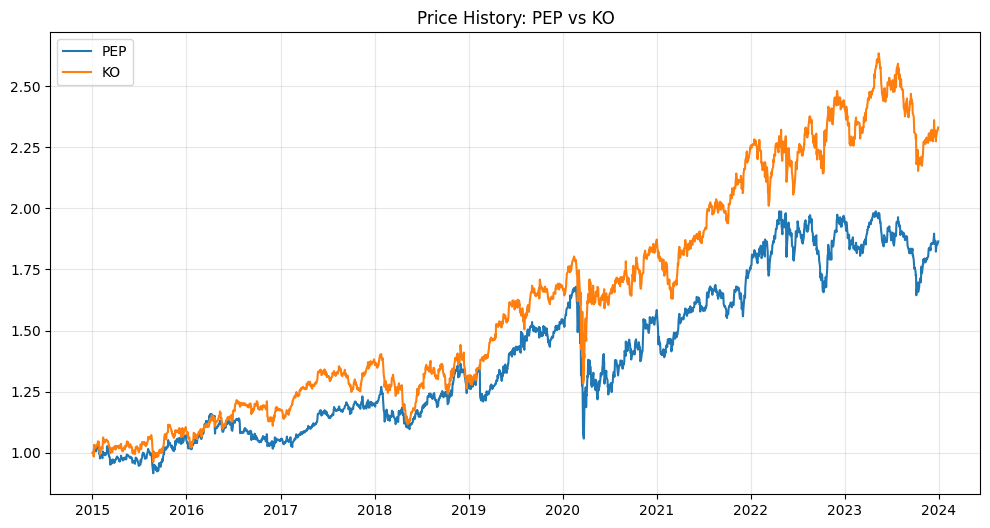

In [4]:
print(f"📥 Downloading Data for {pair}...")
data = yf.download(pair, start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close']
data.dropna(inplace=True)

# Visualize the Prices
# They look correlated, but are they cointegrated?
norm_prices = data / data.iloc[0] # Normalize to start at 1.0 for comparison
plt.figure(figsize=(12, 6))
plt.plot(norm_prices)
plt.title(f"Price History: {pair[0]} vs {pair[1]}")
plt.legend(pair)
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# --- STEP 1: CALCULATE HEDGE RATIO ---
# Regression: PEP = alpha + beta * KO + error
# The 'beta' is our Hedge Ratio.

# Y = Target (PEP), X = Feature (KO)
Y = data['PEP']
X = sm.add_constant(data['KO']) # Add intercept

model = sm.OLS(Y, X).fit()
hedge_ratio = model.params['KO']
print(f"Hedge Ratio: {hedge_ratio:.4f}")
print(f"Explanation: For every 1 share of PEP, we Short {hedge_ratio:.4f} shares of KO.")

Hedge Ratio: 3.3359
Explanation: For every 1 share of PEP, we Short 3.3359 shares of KO.


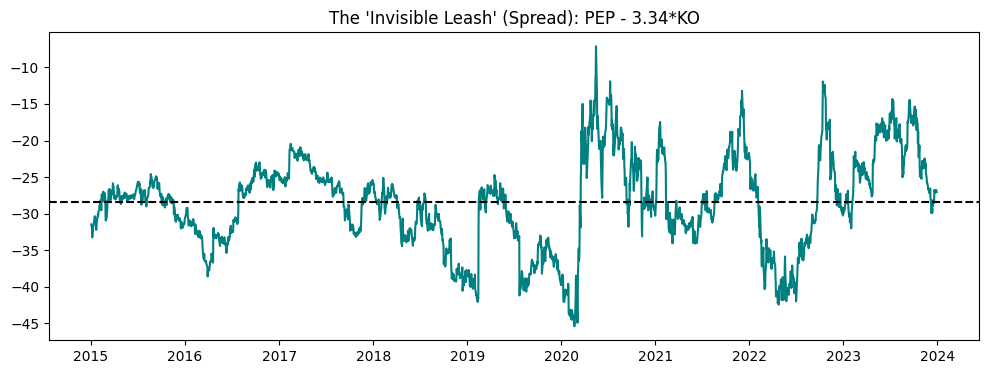

In [7]:
# --- STEP 2: CALCULATE THE SPREAD ---
# Spread = PEP - (Hedge_Ratio * KO)
spread = data['PEP'] - (hedge_ratio * data['KO'])

plt.figure(figsize=(12, 4))
plt.plot(spread, color='teal')
plt.title(f"The 'Invisible Leash' (Spread): PEP - {hedge_ratio:.2f}*KO")
plt.axhline(spread.mean(), color='black', linestyle='--')
plt.show()

In [8]:
# --- STEP 3: ADF TEST (STATIONARITY) ---
# H0: Spread is NOT stationary (Random Walk)
# H1: Spread IS stationary (Mean Reverting)
adf_result = adfuller(spread)
p_value = adf_result[1]

print(f"ADF P-Value: {p_value:.5f}")
if p_value < 0.05:
    print("✅ PASS: The Pair is Cointegrated. We can trade this!")
else:
    print("❌ FAIL: The Spread is a Random Walk. Do NOT trade.")

ADF P-Value: 0.00179
✅ PASS: The Pair is Cointegrated. We can trade this!


In [9]:
# --- SIGNAL GENERATION ---

# 1. Rolling Statistics (Lookback Window)
# We use a 30-day window to define "Normal"
window = 30
spread_mean = spread.rolling(window).mean()
spread_std = spread.rolling(window).std()

In [10]:
# 2. Z-Score
z_score = (spread - spread_mean) / spread_std

# 3. Trade Logic
signals = pd.DataFrame(index=z_score.index)
signals['Z'] = z_score

In [11]:
# Entry/Exit Thresholds
ENTRY_THRESHOLD = 2.0
EXIT_THRESHOLD = 0.0

# Initialize positions
signals['Long_Spread'] = 0
signals['Short_Spread'] = 0
signals['Position'] = 0 # 1 = Long Spread, -1 = Short Spread

In [12]:
# --- ITERATIVE BACKTEST LOGIC ---
# (Vectorized is harder with state-dependent exits, so we loop)
# "State Machine" logic is safer for Mean Reversion

current_pos = 0 # 0=Flat, 1=Long, -1=Short

pos_history = []

for z in signals['Z']:

    # CASE: FLAT
    if current_pos == 0:
        if z < -ENTRY_THRESHOLD: # Spread is too low -> Buy Spread
            current_pos = 1
        elif z > ENTRY_THRESHOLD: # Spread is too high -> Sell Spread
            current_pos = -1

    # CASE: LONG SPREAD (Held PEP, Short KO)
    elif current_pos == 1:
        if z >= -EXIT_THRESHOLD: # Reverted to Mean -> Exit
            current_pos = 0
        # Else: Hold

    # CASE: SHORT SPREAD (Short PEP, Long KO)
    elif current_pos == -1:
        if z <= EXIT_THRESHOLD: # Reverted to Mean -> Exit
            current_pos = 0
        # Else: Hold

    pos_history.append(current_pos)

signals['Position'] = pos_history

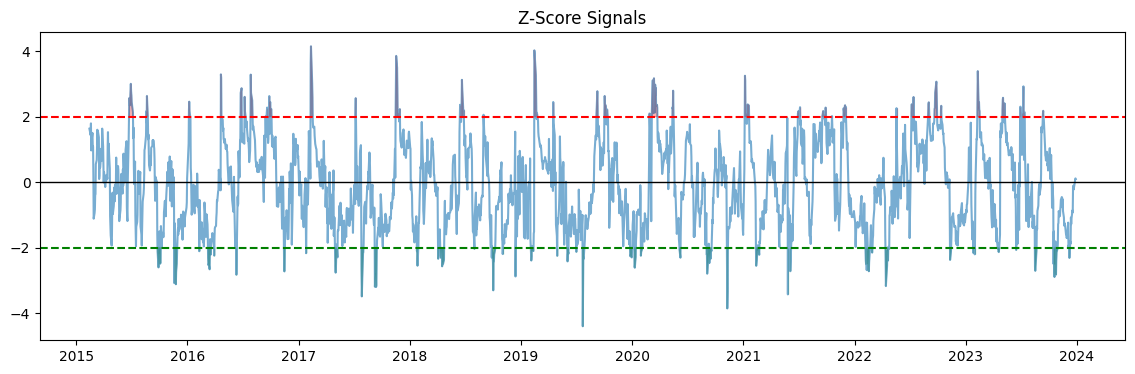

In [13]:
# Plot Z-Score and Trades
plt.figure(figsize=(14, 4))
plt.plot(signals['Z'], label='Z-Score', alpha=0.6)
plt.axhline(ENTRY_THRESHOLD, color='red', linestyle='--')
plt.axhline(-ENTRY_THRESHOLD, color='green', linestyle='--')
plt.axhline(0, color='black', linewidth=1)
plt.fill_between(signals.index, signals['Z'], ENTRY_THRESHOLD, where=(signals['Z']>ENTRY_THRESHOLD), color='red', alpha=0.3)
plt.fill_between(signals.index, signals['Z'], -ENTRY_THRESHOLD, where=(signals['Z']<-ENTRY_THRESHOLD), color='green', alpha=0.3)
plt.title("Z-Score Signals")
plt.show()

In [14]:
# --- PnL CALCULATION ---

# Return of the Spread itself?
# Approximately: Position * (Ret_PEP - HedgeRatio * Ret_KO)
# This is a simplification. In reality, you manage cash balances.

# Let's compute individual leg returns
ret_pep = data['PEP'].pct_change()
ret_ko = data['KO'].pct_change()

In [15]:
# Net Strategy Return
# If Position = 1 (Long Spread): Gain if PEP up, Lose if KO up (Short)
# Note: Hedge ratio is roughly dollar-neutral, but strictly it's share-neutral.
# We approximate spread return as:
strat_ret = signals['Position'].shift(1) * (ret_pep - hedge_ratio * ret_ko)

# Note: Since we are Long 1 share PEP and Short N shares KO, we need to divide by capital base.
# For simplicity in this demo, we assume the 'spread return' is the return on capital.

# Benchmark (Buy and Hold PEP)
bench_ret = ret_pep

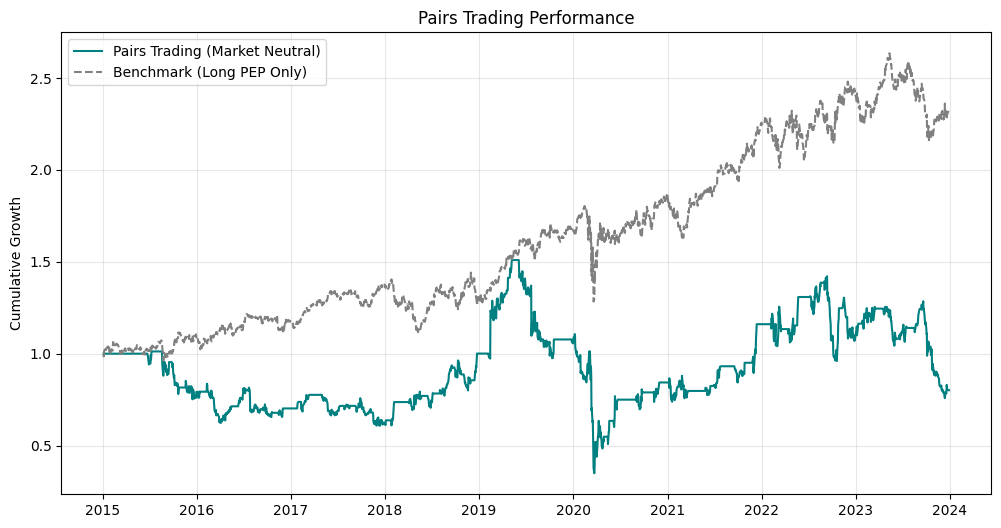

In [16]:
# Cumulative
strat_eq = (1 + strat_ret).cumprod()
bench_eq = (1 + bench_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(strat_eq, label='Pairs Trading (Market Neutral)', color='teal')
plt.plot(bench_eq, label='Benchmark (Long PEP Only)', color='gray', linestyle='--')
plt.title("Pairs Trading Performance")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# --- ALPHA AUDIT ---

audit_df = pd.DataFrame({
    'Strat': strat_ret,
    'Bench': data['PEP'].pct_change() # Using PEP as the "Market" proxy for this sector, or use SPY
}).dropna()

In [20]:
# Let's download SPY for a true "Market Neutral" test
spy = yf.download('SPY', start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close'].pct_change()
audit_df['Market'] = spy

# Re-align indices
audit_df.dropna(inplace=True)
audit_df.head()

,Strat,Bench,Market
Date,,,
2015-01-05,-0.0,-0.007518,-0.018060
2015-01-06,-0.0,-0.007576,-0.009419
2015-01-07,-0.0,0.029241,0.012461
2015-01-08,-0.0,0.018174,0.017745
2015-01-09,0.0,-0.006771,-0.008014


In [21]:
# 1. Regression vs SPY (True Market Neutrality Test)
slope, intercept, r, p, err = stats.linregress(audit_df['Market'], audit_df['Strat'])

beta = slope
alpha_ann = intercept * 252 # Daily data
r_sq = r**2

📊 STATISTICAL ARBITRAGE AUDIT
-----------------------------
Sharpe Ratio:       0.13     <-- Goal: > 1.5
Beta (vs SPY):      0.3764     <-- Goal: 0.00 (Market Neutral)
Alpha (Annualized): 0.11%
Correlation to Mkt: 0.1774


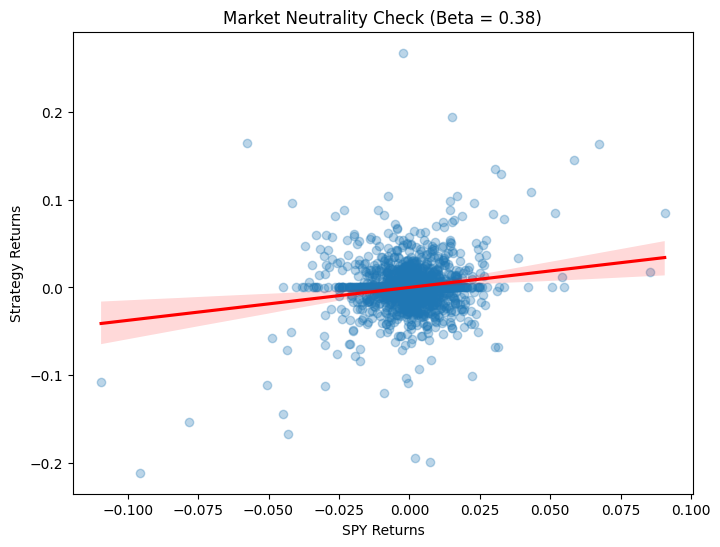

In [22]:
# 2. Sharpe Ratio
sharpe = audit_df['Strat'].mean() / audit_df['Strat'].std() * np.sqrt(252)

print("📊 STATISTICAL ARBITRAGE AUDIT")
print(f"-----------------------------")
print(f"Sharpe Ratio:       {sharpe:.2f}     <-- Goal: > 1.5")
print(f"Beta (vs SPY):      {beta:.4f}     <-- Goal: 0.00 (Market Neutral)")
print(f"Alpha (Annualized): {alpha_ann*100:.2f}%")
print(f"Correlation to Mkt: {r:.4f}")

# Visualizing Market Neutrality
plt.figure(figsize=(8, 6))
sns.regplot(x='Market', y='Strat', data=audit_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f"Market Neutrality Check (Beta = {beta:.2f})")
plt.xlabel("SPY Returns")
plt.ylabel("Strategy Returns")
plt.show()